In [1]:
import numpy as np
import matplotlib
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

In [2]:
# the continuum example
def psi(x, theta):
    return np.cos(theta) * np.sin(x) + np.sin(theta) * np.sin(2 * x)


def rho(x, theta):
    return psi(x, theta) ** 2 / np.pi


def eloc(x, theta):
    return (np.cos(theta) * np.sin(x) + 4 * np.sin(theta) * np.sin(2 * x)) / psi(
        x, theta
    )


def dlogpsi(x, theta):
    return (-np.sin(theta) * np.sin(x) + np.cos(theta) * np.sin(2 * x)) / psi(x, theta)


def sample_from_psi_squared(theta, num_samples=10000):
    x_min, x_max = -np.pi, np.pi
    x_proposal = np.random.uniform(x_min, x_max, size=num_samples * 5)
    y_proposal = np.random.uniform(0, 1, size=num_samples * 5)
    p_vals = rho(x_proposal, theta)
    p_max = p_vals.max() * 1.05
    accept = y_proposal < p_vals / p_max
    x_accepted = x_proposal[accept]
    return x_accepted[:num_samples]

In [3]:
# the blurred sampling for continuum example
def gen_batch_samples_with_shift(theta, num_samples=10000000, batch=1000, eps=0.05):
    x_samples = sample_from_psi_squared(theta, num_samples=num_samples)
    x_samples_batch = x_samples[: batch * (len(x_samples) // batch)].reshape(
        [-1, batch]
    )
    idx_rand = np.random.randint(0, 3, np.shape(x_samples_batch))
    shift = np.array([0, -1, 1])[idx_rand]
    x_samples_bridge_batch = x_samples_batch + shift * eps
    return x_samples_batch, x_samples_bridge_batch


# eloc without blurred
def eloc_dlogpsi(x_samples_batch, theta):
    eloc_ = eloc(x_samples_batch, theta)
    dlogpsi_ = dlogpsi(x_samples_batch, theta)
    eloc_batch = (eloc_).mean(-1)
    gradient_batch = ((eloc_ - eloc_batch[:, None]) * dlogpsi_).mean(-1)
    return eloc_batch, gradient_batch


# reweighting factor
def reweighting_factor(x, theta, eps=0.05):
    return 1 / (
        1 / 3 * ((rho(x + eps, theta) + rho(x - eps, theta)) / rho(x, theta) + 1)
    )


# eloc with blurred
def eloc_dlogpsi_bridge(x_samples_bridge_batch, theta, eps):
    omega = reweighting_factor(x_samples_bridge_batch, theta, eps)
    eloc_bridge = eloc(x_samples_bridge_batch, theta)
    dlogpsi_bridge = dlogpsi(x_samples_bridge_batch, theta)
    omega_mean = omega.mean(-1)
    eloc_bridge_batch = (eloc_bridge * omega).mean(-1) / omega_mean
    gradient_bridge_batch = (
        (eloc_bridge - eloc_bridge_batch[:, None]) * dlogpsi_bridge * omega
    ).mean(-1) / omega_mean
    return eloc_bridge_batch, gradient_bridge_batch

In [4]:
eps = 0.2
theta = np.pi / 4
np.random.seed(42)
gradients_with_blur = []
gradients_without_blur = []
for i in range(100):
    print(i)
    x_samples_batch, x_samples_bridge_batch = gen_batch_samples_with_shift(
        theta, num_samples=10000000, batch=1000, eps=eps
    )
    _, gradient_bridge_batch_ = eloc_dlogpsi_bridge(
        x_samples_bridge_batch, theta, eps
    )
    _, gradient_batch_ = eloc_dlogpsi(x_samples_batch, theta)

    gradients_with_blur.append(gradient_bridge_batch_)
    gradients_without_blur.append(gradient_batch_)

gradients_with_blur = np.concatenate(gradients_with_blur)
gradients_without_blur = np.concatenate(gradients_without_blur)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [5]:
np.save("gradients_without_blur.npy", gradients_without_blur)
np.save("gradients_with_blur.npy", gradients_with_blur)

In [8]:
gradients_without_blur = np.load("gradients_without_blur.npy")
gradients_with_blur = np.load("gradients_with_blur.npy")

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <

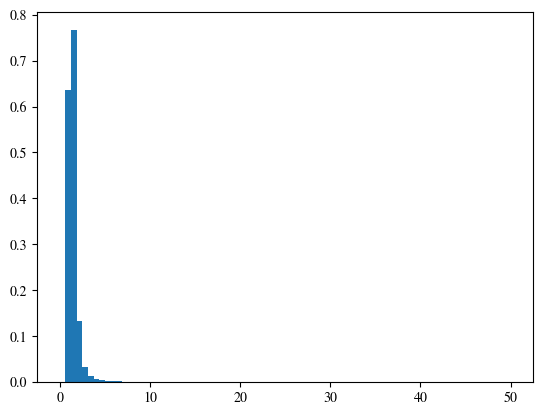

In [9]:
# fitting the tail with x > 5
from scipy.optimize import curve_fit

res = plt.hist(
    gradients_without_blur, 80, [0, 50], density=True
)
x_ = (res[1][:-1] + res[1][1:]) / 2
f_ = res[0]
mask = x_ > 5
x_ = x_[mask]
f_ = f_[mask]


def model(x, c):
    return c * (x - 1.5) ** (-2.5)

const, _ = curve_fit(model, x_, f_)

In [10]:
def sample_from_psi(theta, nsamples):
    return np.array(
        np.random.uniform(0, 1, [nsamples]) < np.sin(theta) ** 2, dtype=np.int64
    )


def vmc_step(theta, nsamples, q=0):
    samples = sample_from_psi(theta, nsamples)

    psi0 = np.cos(theta)
    psi1 = np.sin(theta)
    p0 = np.abs(psi0)**2
    p1 = np.abs(psi1)**2
    if q != 0:
        mask = np.random.uniform(0, 1, [nsamples]) < q
        samples = (mask + samples) % 2
        r_samples = ((1 - q) * p0 + q * p1) * (
            1 - samples
        )
        r_samples += ((1 - q) * p1 + q * p0) * samples
    else:
        r_samples = p0 * (1 - samples) + p1 * (samples)
        
    Eloc_psi = psi1 * (1 - samples) + psi0 * samples
    Eloc_p = psi1 * np.conj(psi0) * (1 - samples) + psi0 * np.conj(psi1) * samples
    O_psi = -np.sin(theta) * (1 - samples) + np.cos(theta) * samples
    O_p = (
        -np.sin(theta) * np.conj(psi0) * (1 - samples)
        + np.cos(theta) * np.conj(psi1) * samples
    )
    Eloc_mean = np.mean(Eloc_p / r_samples)
    O_mean = np.mean(O_p / r_samples)
    return (
        np.mean(np.conj(O_psi) * Eloc_psi / r_samples) - np.conj(O_mean) * Eloc_mean,
        np.mean(np.conj(O_psi) * O_psi / r_samples ) - np.conj(O_mean) * (O_mean),
        Eloc_mean,
    )

In [11]:
np.random.seed(42)
theta_list = np.arange(-np.pi / 4, np.pi / 4, 0.005)
gradient_without_bridge = [vmc_step(theta, 1000, 0)[0] for theta in theta_list]
gradient_blur_1 = [vmc_step(theta, 1000, 0.1)[0] for theta in theta_list]
gradient_blur_5 = [vmc_step(theta, 1000, 0.5)[0] for theta in theta_list]

In [12]:
# S matrix regularization
eta = 1e-18
lr = 0.01

# without blur
np.random.seed(42)
theta = np.pi / 3
E_list_without_blur = []
for i in range(500):
    grad, s, Eloc_mean = vmc_step(theta, 1000, 0)
    theta -= lr * grad / (s + eta)
    if i > 900:
        print(grad,s, theta,lr * grad / (s + eta))
    E_list_without_blur.append(Eloc_mean)
    
# blur q = 0.1
np.random.seed(42)
theta = np.pi / 3
E_list_with_blur_1 = []
for i in range(500):
    grad, s, Eloc_mean = vmc_step(theta, 1000, 0.1)
    theta -= lr * grad / (s + eta)
    E_list_with_blur_1.append(Eloc_mean)

# blur q = 0.5
np.random.seed(42)
theta = np.pi / 3
E_list_with_blur_5 = []
for i in range(500):
    grad, s, Eloc_mean = vmc_step(theta, 1000, 0.5)
    theta -= lr * grad / (s + eta)
    E_list_with_blur_5.append(Eloc_mean)

/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


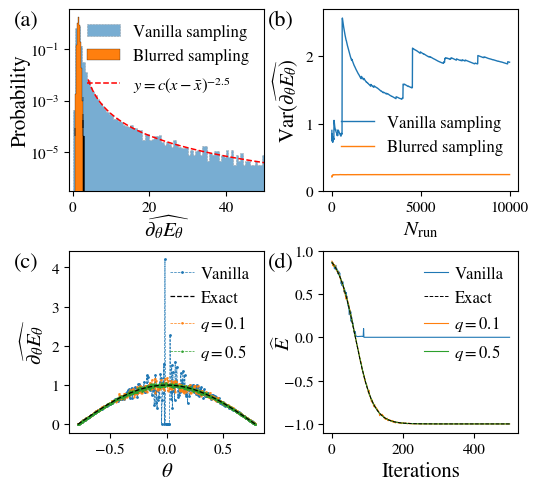

In [13]:
fig = plt.figure(figsize=(5.8, 5.5))
gs = GridSpec(2, 2, figure=fig, width_ratios=[1, 1], wspace=0.3, hspace=0.33)
ax1 = fig.add_subplot(gs[0, :1])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :1])
ax4 = fig.add_subplot(gs[1, 1])

_ = ax1.hist(
    gradients_without_blur, 80, [0, 50], density=True, alpha=0.6, label="Vanilla sampling", histtype="stepfilled",linestyle="--",linewidth=0.4,edgecolor="grey"
)
_ = ax1.hist(
    gradients_with_blur, 100, density=True, alpha=1.0, label="Blurred sampling", edgecolor="black",linewidth=0.2, zorder=10,histtype="stepfilled"
)

ax1.plot(
    np.arange(4, 100, 0.1),
    (np.arange(4, 100, 0.1) - 1.5) ** (-2.5) * const,
    "r--",
    lw=1.1,
    label=r"$y = c(x-\bar{x})^{-2.5}$",
)
ax1.legend(frameon=False, fontsize=12)
ax1.set_xlabel(r"$\widehat{\partial_\theta E_\theta}$", fontsize=15, labelpad=-1)
ax1.set_ylabel(r"Probability", fontsize=15, labelpad=-0.4)
ax1.set_xlim(-1, 50)
# ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.tick_params(labelsize=11)


ax2.plot(
    [x * 10 for x in range(1000)],
    [np.std(gradients_without_blur[: x * 100]) for x in range(1000)],
    label="Vanilla sampling",
    lw=1,
)
ax2.plot(
    [x * 10 for x in range(1000)],
    [np.std(gradients_with_blur[: x * 100]) for x in range(1000)],
    label="Blurred sampling",
    lw=1,
)
ax2.legend(
    frameon=False,
    fontsize=12,
    loc="upper right",
    bbox_to_anchor=(1.0, 0.5),
)
ax2.set_xlabel(r"$N_\text{run}$", fontsize=15)
ax2.set_ylabel(r"Var($\widehat{\partial_\theta E_\theta}$)", fontsize=15)
ax2.tick_params(labelsize=11)
ax2.set_ylim(0, 2.7)


ax3.set_xlabel(r"$\theta$", fontsize=15)
ax3.set_ylabel(r"$\widehat{\partial_\theta E_\theta}$", fontsize=15)
ax3.plot(theta_list, gradient_without_bridge, "o--", lw=0.5, ms=1, label="Vanilla")
ax3.plot(
    theta_list, np.cos(theta_list * 2), "k--", lw=0.9, ms=1, label="Exact", zorder=10
)
ax3.plot(theta_list, gradient_blur_1, "v--", lw=0.5, ms=1, label=r"$q=0.1$")
ax3.plot(theta_list, gradient_blur_5, "^--", lw=0.5, ms=1, label=r"$q=0.5$")
ax3.legend(frameon=False, fontsize=12, ncols=1, columnspacing=0.1, handletextpad=0.4, handlelength=1.4, loc="upper right")
ax3.tick_params(labelsize=11)

ax4.plot(E_list_without_blur, "-", lw=0.8, ms=1.5, label=r"Vanilla")
ax4.plot(
    np.arange(500),
    (
        -np.cos(np.pi / 3 + np.pi / 4) ** 2 * np.exp(2 * np.arange(500) * lr)
        + np.sin(np.pi / 3 + np.pi / 4) ** 2 * np.exp(-2 * np.arange(500) * lr)
    )
    / (
        np.cos(np.pi / 3 + np.pi / 4) ** 2 * np.exp(2 * np.arange(500) * lr)
        + np.sin(np.pi / 3 + np.pi / 4) ** 2 * np.exp(-2 * np.arange(500) * lr)
    ),
    "k--",
    lw=0.7,
    label=r"Exact",
    zorder=10,
)
ax4.plot(E_list_with_blur_1, "-", lw=0.8, ms=1.5, label=r"$q=0.1$")
ax4.plot(E_list_with_blur_5, "-", lw=0.8, ms=1.5, label=r"$q=0.5$")
ax4.legend(frameon=False, fontsize=12, ncols=1, columnspacing=0.1, handletextpad=0.4, handlelength=1.4)
ax4.set_xlabel("Iterations", fontsize=15)
ax4.set_ylabel(r"$\widehat{E}$", fontsize=15, labelpad=-8)
ax4.set_ylim(-1.1, 1.0)
ax4.tick_params(labelsize=11)
loc_x = -0.28
loc_y = 0.91
fs = 16
ax1.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
ax2.annotate("(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
ax3.annotate("(c)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
ax4.annotate("(d)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=fs)
plt.savefig("Fig2.pdf", bbox_inches="tight", pad_inches=0.01)